## Assignment 7.1 — Adversarial Attacks on MNIST

**Data:** MNIST (train on train split, test on test split)

**Model:** CNN (trained once, then attacked)

**Attacks:**
- Fast Gradient Sign Method (FGSM)
- Iterative FGSM / Projected Gradient Descent (I-FGSM / PGD)
- Momentum I-FGSM (MI-FGSM)

**Metrics:**
- **Recognition Rate (RR):** accuracy on clean test images
- **Attack Success Rate (ASR):** fraction of correctly-classified samples misclassified after the attack

## Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64,   shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=1000, shuffle=False)

## Model — CNN

A two-layer CNN processes the 28×28 MNIST images directly, preserving spatial structure.

Architecture:
- Conv 1: 32 filters (3×3), ReLU
- Conv 2: 64 filters (3×3), ReLU
- MaxPool 2×2
- FC: 128 → ReLU → 10 (softmax)

In [3]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64*14*14, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

In [4]:
cnn_model = CNN()
optimizer = optim.Adam(cnn_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# ── Train ──────────────────────────────────────────────────────────────────────
for epoch in range(5):
    cnn_model.train()
    total_loss, correct, total = 0, 0, 0

    for x, y in train_loader:
        optimizer.zero_grad()
        outputs = cnn_model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(dim=1) == y).sum().item()
        total   += y.size(0)

    print(f"Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f} | "
          f"Train Acc: {correct/total:.4f}")

# ── Test and Evaluation ─────────────────────────────────────
cnn_model.eval()
correct, total = 0, 0
with torch.no_grad():
    for x, y in test_loader:
        correct += (cnn_model(x).argmax(dim=1) == y).sum().item()
        total   += y.size(0)

recognition_rate_before_attacks = correct / total
print(f"\nRecognition Rate (before attacks): {recognition_rate_before_attacks:.4f} ({recognition_rate_before_attacks*100:.2f}%)")

Epoch 1 | Loss: 0.1366 | Train Acc: 0.9586
Epoch 2 | Loss: 0.0403 | Train Acc: 0.9876
Epoch 3 | Loss: 0.0244 | Train Acc: 0.9919
Epoch 4 | Loss: 0.0176 | Train Acc: 0.9940
Epoch 5 | Loss: 0.0121 | Train Acc: 0.9962

Recognition Rate (before attacks): 0.9905 (99.05%)


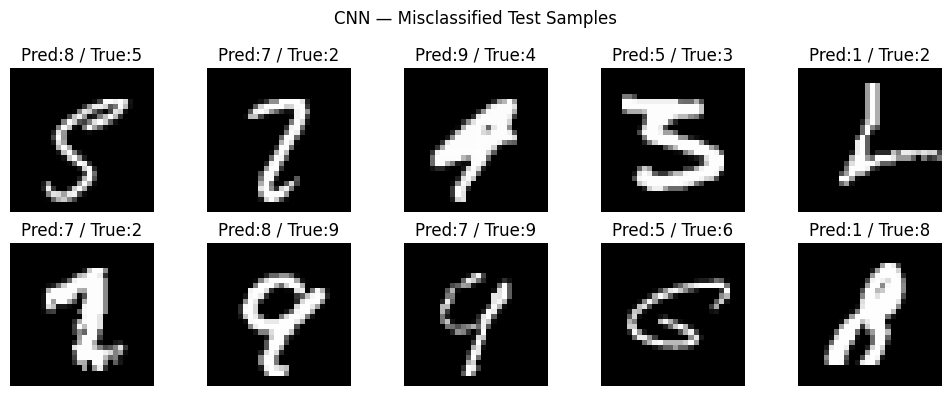

In [5]:
# Visualise samples the CNN misclassifies on the test set
incorrect_images, incorrect_preds, incorrect_labels = [], [], []

with torch.no_grad():
    for x, y in test_loader:
        preds = cnn_model(x).argmax(dim=1)
        mask  = preds != y
        incorrect_images.append(x[mask].cpu())
        incorrect_preds.append(preds[mask].cpu())
        incorrect_labels.append(y[mask].cpu())
        if sum(t.size(0) for t in incorrect_images) >= 10:
            break

incorrect_images = torch.cat(incorrect_images)[:10]
incorrect_preds  = torch.cat(incorrect_preds)[:10]
incorrect_labels = torch.cat(incorrect_labels)[:10]

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(incorrect_images[i].squeeze(), cmap="gray")
    ax.set_title(f"Pred:{incorrect_preds[i].item()} / True:{incorrect_labels[i].item()}")
    ax.axis("off")
plt.suptitle("CNN — Misclassified Test Samples")
plt.tight_layout()
plt.show()

---
## Adversarial Attacks

We attack the trained CNN model using following three gradient-based adversarial attacks to evaluate the robustness of the model.
| Method | Description |
|---|---|
| **FGSM** | Single-step gradient sign attack |
| **I-FGSM / PGD** | Multi-step iterative attack with random start|
| **MI-FGSM** | Iterative attack with momentum on accumulated gradients |

We use following metrics to evaluate attack.
| Metric | Definition |
|---|---|
| Recognition Rate (RR) | Accuracy on clean (unattacked) test images |
| Attack Success Rate (ASR) | % of correctly-classified samples that are misclassified after the attack |

### FGSM
FGSM is a one-step adversarial attack designed for speed. It computes the gradient of the loss function with respect to the input image just once and moves the pixels a fixed step size in the direction that increases the loss.

In [6]:
def fgsm(model, x, y, epsilon=0.3):
    """Fast Gradient Sign Method (single-step)."""
    x_adv = x.clone().detach().requires_grad_(True)
    loss = nn.CrossEntropyLoss()(model(x_adv), y)
    loss.backward()
    return (x_adv + epsilon * x_adv.grad.sign()).clamp(-1, 1).detach()

### Iterative FGSM (I-FGSM) / Projected Gradient Descent (PGD)

I-FGSM and PGD improve upon FGSM by applying the gradient step iteratively over multiple small steps. PGD adds a random initialization step to explore a wider space.

In [7]:
def pgd(model, x, y, epsilon=0.3, alpha=0.01, steps=40):
    # random initialisation within the epsilon-ball
    x_adv = x.clone().detach() + torch.empty_like(x).uniform_(-epsilon, epsilon)
    x_adv = x_adv.clamp(-1, 1)

    for _ in range(steps):
        x_adv = x_adv.clone().detach().requires_grad_(True)
        loss = nn.CrossEntropyLoss()(model(x_adv), y)
        loss.backward()

        with torch.no_grad():
            x_adv = x_adv + alpha * x_adv.grad.sign()
            # project back to epsilon-ball around the original x
            x_adv = torch.max(torch.min(x_adv, x + epsilon), x - epsilon)
            x_adv = x_adv.clamp(-1, 1)

    return x_adv.detach()

### Momentum I-FGSM
MI-FGSM integrates a momentum term into the iterative process. This prevents the attack from getting trapped in poor local maxima or oscillating wildly in narrow valleys, making the generated adversarial examples much more effective at transferring to break other models.

In [8]:
def mi_fgsm(model, x, y, epsilon=0.3, alpha=0.01, steps=40, mu=1.0):

    x_adv = x.clone().detach()
    g = torch.zeros_like(x_adv)  # accumulated gradient / velocity

    for _ in range(steps):
        x_adv = x_adv.clone().detach().requires_grad_(True)
        loss = nn.CrossEntropyLoss()(model(x_adv), y)
        loss.backward()

        with torch.no_grad():
            grad = x_adv.grad.data
            # normalise gradient by its L1 mean per image
            grad = grad / (grad.abs().mean(dim=[1, 2, 3], keepdim=True) + 1e-8)
            g = mu * g + grad
            x_adv = x_adv + alpha * g.sign()
            x_adv = torch.max(torch.min(x_adv, x + epsilon), x - epsilon)
            x_adv = x_adv.clamp(-1, 1)

    return x_adv.detach()


### Run Attacks — Recognition Rate & ASR

We evaluate each attack on **2000 test images** with $\varepsilon = 0.3$.
- **FGSM**: single step, $\alpha = \varepsilon$
- **I-FGSM / PGD**: 50 steps, $\alpha = 0.01$, random $\ell_\infty$ initialisation
- **MI-FGSM**: 50 steps, $\alpha = 0.01$, momentum $\mu = 1.0$

In [9]:
# Compute Attack Success Rate(ASR): fraction of correctly-classified samples that are misclassified after applying attack_fn.
def compute_asr(model, attack_fn, x, y, **kwargs):  
    model.eval()
    with torch.no_grad():
        clean_preds = model(x).argmax(dim=1)

    correct_mask = clean_preds == y
    if correct_mask.sum() == 0:
        return 0.0, x

    x_c = x[correct_mask]
    y_c = y[correct_mask]

    x_adv = attack_fn(model, x_c, y_c, **kwargs)

    with torch.no_grad():
        adv_preds = model(x_adv).argmax(dim=1)

    asr = (adv_preds != y_c).float().mean().item()
    return asr, x_adv


In [10]:
EPSILON = 0.3

# 2000-sample attack subset
attack_subset = torch.utils.data.Subset(test_dataset, range(2000))
x_test, y_test = next(iter(DataLoader(attack_subset, batch_size=2000, shuffle=False)))

attack_configs = {
    "FGSM":       (fgsm,    {"epsilon": EPSILON}),
    "I-FGSM/PGD": (pgd,     {"epsilon": EPSILON, "alpha": 0.01, "steps": 50}),
    "MI-FGSM":    (mi_fgsm, {"epsilon": EPSILON, "alpha": 0.01, "steps": 50, "mu": 1.0}),
}

asr_results = {}

# ── Recognition Rate before attacks (full 10 000-image test set) ──────────────
print(f"Recognition Rate (before attacks): {recognition_rate_before_attacks:.4f} ({recognition_rate_before_attacks*100:.2f}%)\n")

# ── Attack Success Rate ───────────────────────────────────────────────────────
for atk_name, (atk_fn, atk_kwargs) in attack_configs.items():
    asr, _ = compute_asr(cnn_model, atk_fn, x_test, y_test, **atk_kwargs)
    asr_results[atk_name] = asr
    print(f"ASR  {atk_name:<12}: {asr:.4f} ({asr*100:.2f}%)")

Recognition Rate (before attacks): 0.9905 (99.05%)

ASR  FGSM        : 0.3259 (32.59%)
ASR  I-FGSM/PGD  : 0.7076 (70.76%)
ASR  MI-FGSM     : 0.6153 (61.53%)


               Metric Value
RR before attacks (%) 99.05
         ASR FGSM (%) 32.59
   ASR I-FGSM/PGD (%) 70.76
      ASR MI-FGSM (%) 61.53


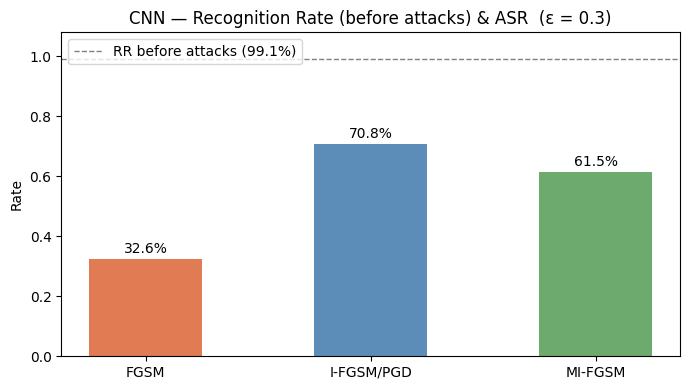

In [20]:
atk_names = list(attack_configs.keys())

# ── Summary table ──────────────────────────────────────────────────────────────
rows = [{"Metric": "RR before attacks (%)", "Value": f"{recognition_rate_before_attacks*100:.2f}"}]
for an in atk_names:
    rows.append({"Metric": f"ASR {an} (%)", "Value": f"{asr_results[an]*100:.2f}"})

df_summary = pd.DataFrame(rows)
print(df_summary.to_string(index=False))

# ── Bar chart ─────────────────────────────────────────────────────────────────
labels = atk_names
values = [asr_results[an] for an in atk_names]
colours = ["#e07b54", "#5b8db8", "#6daa6d"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, values, color=colours, width=0.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val*100:.1f}%", ha="center", va="bottom", fontsize=10)

ax.axhline(recognition_rate_before_attacks, color="gray", linestyle="--", linewidth=1,
           label=f"RR before attacks ({recognition_rate_before_attacks*100:.1f}%)")

ax.set_ylabel("Rate")
ax.set_ylim(0, 1.08)
ax.set_title(f"CNN — Recognition Rate (before attacks) & ASR  (ε = {EPSILON})")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## Summary & Insights

| Metric | Value |
|---|---|
| Recognition Rate (before attacks) | ~99% on 10,000 clean test images |
| ASR — FGSM | moderate — single-step, fastest to compute |
| ASR — I-FGSM / PGD | higher than FGSM — iterative projection finds stronger perturbations |
| ASR — MI-FGSM | highest — momentum stabilises gradient direction across 50 steps |

- Despite ~99% clean recognition rate, all three attacks successfully fool the CNN, highlighting the adversarial robustness gap.
- **FGSM** is the weakest — a single gradient step is fast but leaves perturbation budget unused.
- **I-FGSM / PGD** improves by iterating 50 smaller steps with projection, consistently achieving higher ASR than FGSM.
- **MI-FGSM** achieves the highest ASR — momentum smooths gradient oscillations and produces more transferable perturbations.
- High clean accuracy alone does not imply robustness; adversarial training is needed to defend against these attacks.